# MNIST One-Class / One-vs-Rest Outlier Detection

**Goal:** treat one digit as **normal** and all others as **outliers**, then train a detector (typically on normal-only) and evaluate on a mixed test set.

**Conventions**
- `y = 0` → normal
- `y = 1` → outlier
- higher anomaly score → more anomalous


In [ ]:
!pip -q install -r ../requirements.txt

In [1]:
import sys
sys.path.append('..')
from common.utils import *

Pulls in helper functions from `common/utils.py`. In this notebook, the ones that matter are:

`set_global_seed(SEED)` – makes RNG behavior reproducible across libraries

`choose_threshold_youden(y, scores)` – picks a classification threshold from validation scores

`confusion_at_threshold(y_true, scores, thr)` – builds a confusion matrix given a threshold

## Data

In [ ]:
SEED = 42
import os
import numpy as np
from sklearn.model_selection import train_test_split

import torch
from torchvision import datasets, transforms

from common.utils import set_global_seed

set_global_seed(SEED)

# --- Config (tune these if WSL memory is tight) ---
DATA_DIR = "./data"
VAL_SIZE = 0.2               # validation split from training pool (normal-only)
MAX_TRAIN_NORMAL = 20000     # cap for speed; set None for full
MAX_VAL_TOTAL = 8000         # cap for speed; set None for full
MAX_TEST_TOTAL = 10000       # cap for speed; set None for full

# --- Load MNIST once ---
tfm = transforms.ToTensor()
train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=tfm)
test_full  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=tfm)

def to_numpy(ds):
    X = ds.data.numpy().astype(np.float32) / 255.0  # [N, 28, 28]
    y = ds.targets.numpy().astype(int)
    return X, y

Xtr_all, ytr_all = to_numpy(train_full)
Xte_all, yte_all = to_numpy(test_full)

def build_splits_for_normal_digit(normal_digit: int):
    """
    Build (train normals only), (val balanced: normals+outliers), (test: full test set mapped to 0/1)
    Does not return y_train because we are training only using normal samples (one class)
    Returns:
      X_train_flat, X_val_flat, X_test_flat, y_val, y_test
    """
    NORMAL_DIGITS = [int(normal_digit)]
    rng = np.random.default_rng(SEED + int(normal_digit))

    # --- normal-only pool (train/val) ---
    normal_mask = np.isin(ytr_all, NORMAL_DIGITS)
    X_normal = Xtr_all[normal_mask]

    X_train_n, X_val_n = train_test_split(X_normal, test_size=VAL_SIZE, random_state=SEED, shuffle=True)

    if MAX_TRAIN_NORMAL is not None:
        X_train_n = X_train_n[:MAX_TRAIN_NORMAL]
    if MAX_VAL_TOTAL is not None:
        X_val_n = X_val_n[:MAX_VAL_TOTAL]

    # --- outlier pool (from train split digits != normal) ---
    out_mask = ~np.isin(ytr_all, NORMAL_DIGITS)
    X_out_pool = Xtr_all[out_mask]

    # sample outliers for validation (balanced)
    n_val_out = min(len(X_out_pool), len(X_val_n))
    out_idx = rng.choice(len(X_out_pool), size=n_val_out, replace=False)
    X_val_out = X_out_pool[out_idx]

    X_val = np.concatenate([X_val_n, X_val_out], axis=0)
    y_val = np.concatenate(
        [np.zeros(len(X_val_n), dtype=int), np.ones(len(X_val_out), dtype=int)],
        axis=0
    )

    # --- test set: full test, mapped to normal vs outlier ---
    # 0 = normal digits, 1 = outlier
    X_test = Xte_all
    y_test = (~np.isin(yte_all, NORMAL_DIGITS)).astype(int)

    if MAX_TEST_TOTAL is not None:
        X_test = X_test[:MAX_TEST_TOTAL]
        y_test = y_test[:MAX_TEST_TOTAL]

    # Flatten
    X_train_flat = X_train_n.reshape(len(X_train_n), -1)
    X_val_flat   = X_val.reshape(len(X_val), -1)
    X_test_flat  = X_test.reshape(len(X_test), -1)

    return X_train_flat, X_val_flat, X_test_flat, y_val, y_test

# Default single setting (kept for quick sanity checks)
NORMAL_DIGITS = [0]
X_train_flat, X_val_flat, X_test_flat, y_val, y_test = build_splits_for_normal_digit(0)
print("Default normal digit:", NORMAL_DIGITS)
print("Train normals:", X_train_flat.shape, "Val mix:", X_val_flat.shape, "Test mix:", X_test_flat.shape)
print("Test outlier rate:", float(y_test.mean()))


Default normal digit: [0]
Train normals: (4738, 784) Val mix: (2370, 784) Test mix: (10000, 784)
Test outlier rate: 0.902


## Model: k-NN distance anomaly score

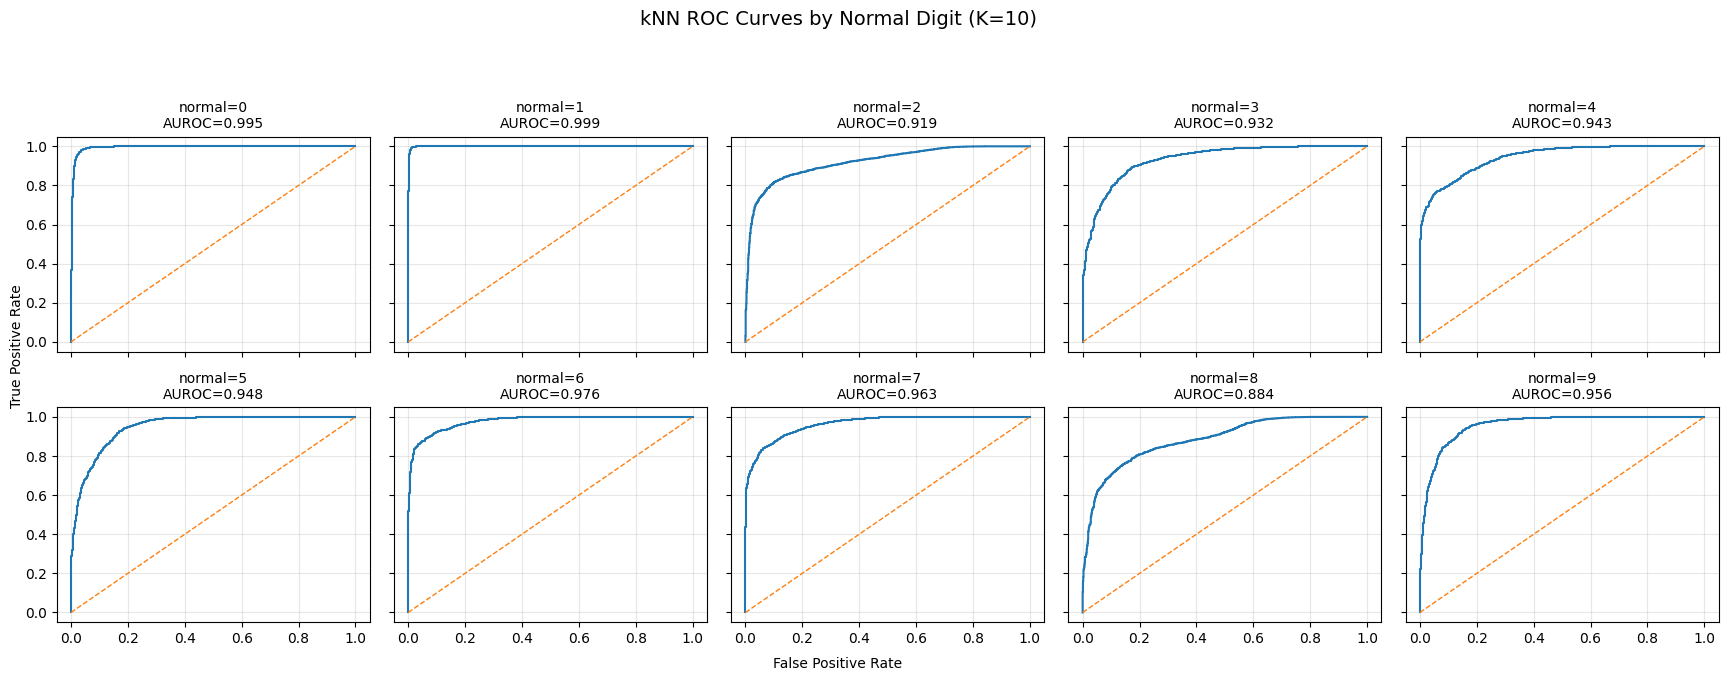

AUROC summary by normal digit:
  normal=0: AUROC=0.9946
  normal=1: AUROC=0.9991
  normal=2: AUROC=0.9195
  normal=3: AUROC=0.9323
  normal=4: AUROC=0.9434
  normal=5: AUROC=0.9484
  normal=6: AUROC=0.9762
  normal=7: AUROC=0.9632
  normal=8: AUROC=0.8838
  normal=9: AUROC=0.9562


/tmp/ipykernel_5920/2153266515.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.03, 0.90, 0.90])


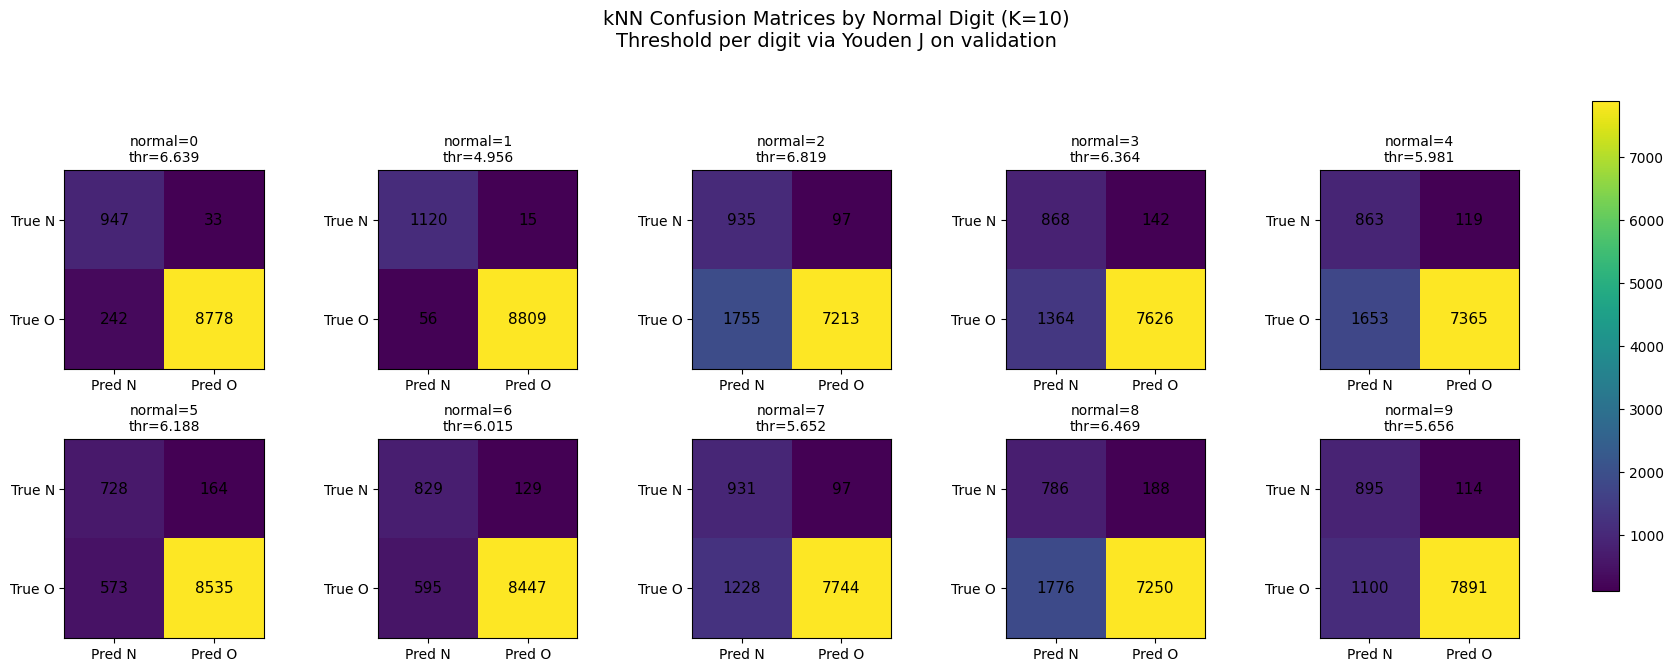

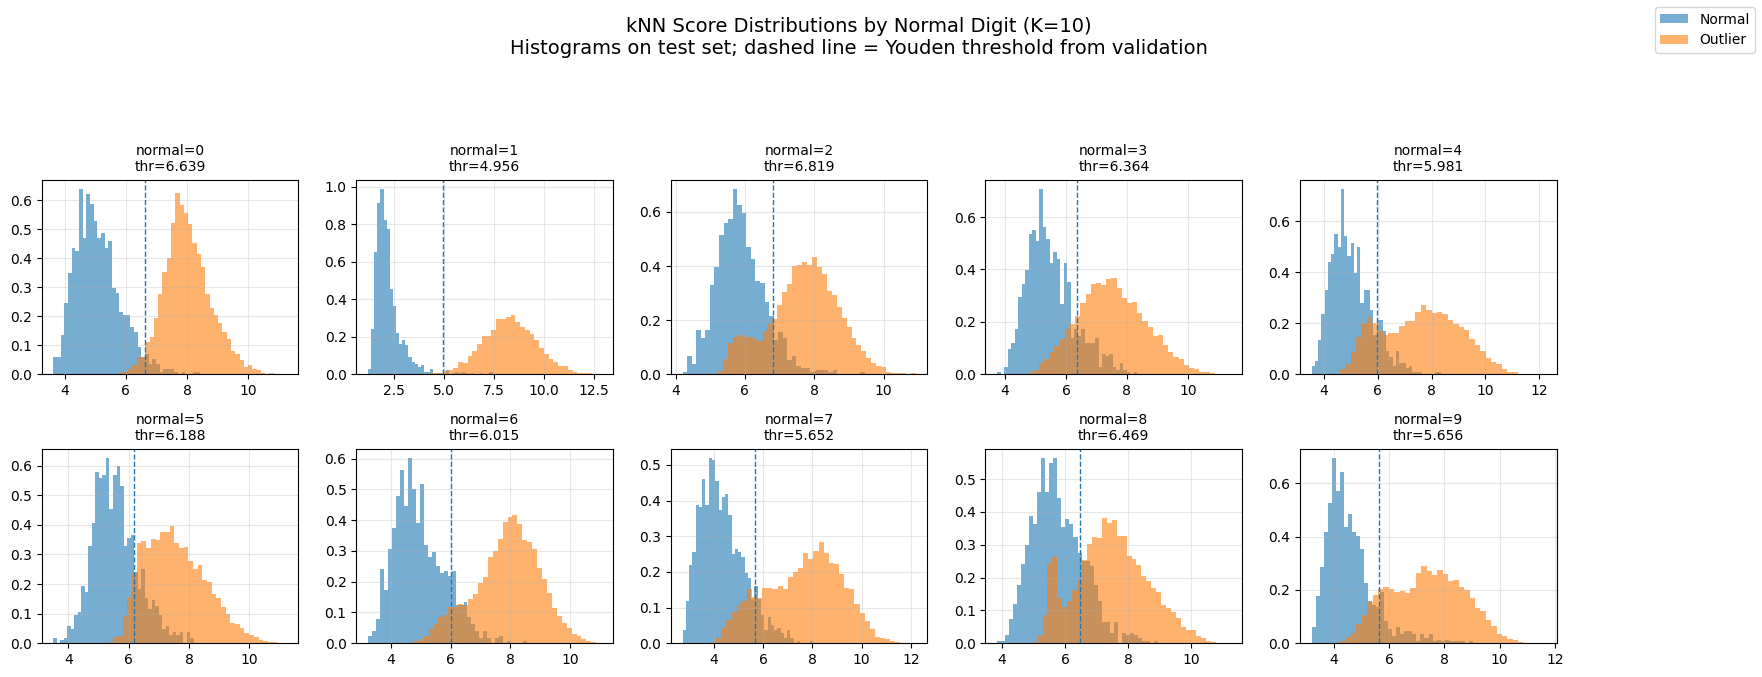

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

from common.utils import choose_threshold_youden, confusion_at_threshold

K = 10  # number of neighbors

# -----------------------------
# 1) ROC curves (2x5 grid)
# -----------------------------
fig_roc, axes_roc = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes_roc = axes_roc.ravel()

aucs = {}
cached_scores = {}   # store (y_test, scores_test, y_val, scores_val, thr, cm) per digit

# loop over 0, 1, ..., 9 as the normal digit
for normal_digit in range(10):
    ax = axes_roc[normal_digit]

    # Build data for this normal digit
    X_train_flat, X_val_flat, X_test_flat, y_val, y_test = build_splits_for_normal_digit(normal_digit)

    # Fit kNN on training data (normal only)
    nn = NearestNeighbors(n_neighbors=K, metric="euclidean", n_jobs=1)  # n_jobs=1 for WSL stability
    nn.fit(X_train_flat)

    # Scores on validation and test set
    scores_val  = nn.kneighbors(X_val_flat,  return_distance=True)[0].mean(axis=1)
    scores_test = nn.kneighbors(X_test_flat, return_distance=True)[0].mean(axis=1)

    # ROC + AUROC
    fpr, tpr, _ = roc_curve(y_test, scores_test)
    auc = float(roc_auc_score(y_test, scores_test))
    aucs[normal_digit] = auc

    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], "--", linewidth=1)
    ax.set_title(f"normal={normal_digit}\nAUROC={auc:.3f}", fontsize=10)
    ax.grid(alpha=0.3)

    # Threshold + confusion matrix (computed now, plotted later)
    thr = float(choose_threshold_youden(y_val, scores_val))
    cm, _ = confusion_at_threshold(y_test, scores_test, thr)

    cached_scores[normal_digit] = (y_test, scores_test, y_val, scores_val, thr, cm)

fig_roc.suptitle(f"kNN ROC Curves by Normal Digit (K={K})", fontsize=14)
fig_roc.text(0.5, 0.04, "False Positive Rate", ha="center")
fig_roc.text(0.04, 0.5, "True Positive Rate", va="center", rotation="vertical")
plt.tight_layout(rect=[0.04, 0.05, 1, 0.92])
plt.show()

print("AUROC summary by normal digit:")
for d in range(10):
    print(f"  normal={d}: AUROC={aucs[d]:.4f}")

# -----------------------------
# 2) Confusion matrices (2x5 grid) — FIXED LAYOUT
# -----------------------------
fig_cm, axes_cm = plt.subplots(2, 5, figsize=(18, 7))
axes_cm = axes_cm.ravel()

last_im = None

for normal_digit in range(10):
    ax = axes_cm[normal_digit]
    _, _, _, _, thr, cm = cached_scores[normal_digit]

    last_im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"normal={normal_digit}\nthr={thr:.3f}", fontsize=10)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred N", "Pred O"])
    ax.set_yticklabels(["True N", "True O"])

    # Annotate cells
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center", fontsize=11)

# ---- create a dedicated colorbar axis (prevents overlap) ----
cbar_ax = fig_cm.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
fig_cm.colorbar(last_im, cax=cbar_ax)

fig_cm.suptitle(
    f"kNN Confusion Matrices by Normal Digit (K={K})\n"
    "Threshold per digit via Youden J on validation",
    fontsize=14
)

# Leave space on the right for colorbar
plt.tight_layout(rect=[0.02, 0.03, 0.90, 0.90])
plt.show()

# -----------------------------
# 3) Score distributions (2x5 grid)
# -----------------------------
fig_sd, axes_sd = plt.subplots(2, 5, figsize=(18, 7), sharex=False, sharey=False)
axes_sd = axes_sd.ravel()

BINS = 40

for normal_digit in range(10):
    ax = axes_sd[normal_digit]

    y_test, scores_test, _, _, thr, _ = cached_scores[normal_digit]

    scores_test = np.asarray(scores_test)
    y_test = np.asarray(y_test).astype(int)

    # Split scores
    s_norm = scores_test[y_test == 0]
    s_out  = scores_test[y_test == 1]

    # Plot histograms
    ax.hist(s_norm, bins=BINS, alpha=0.6, label="Normal", density=True)
    ax.hist(s_out,  bins=BINS, alpha=0.6, label="Outlier", density=True)

    # Show threshold line
    ax.axvline(thr, linestyle="--", linewidth=1)

    ax.set_title(f"normal={normal_digit}\nthr={thr:.3f}", fontsize=10)
    ax.grid(alpha=0.3)

# One shared legend (avoid repeating in every subplot)
handles, labels = axes_sd[0].get_legend_handles_labels()
fig_sd.legend(handles, labels, loc="upper right")

fig_sd.suptitle(f"kNN Score Distributions by Normal Digit (K={K})\n"
                "Histograms on test set; dashed line = Youden threshold from validation",
                fontsize=14)

plt.tight_layout(rect=[0.02, 0.03, 0.90, 0.90])
plt.show()
